# Please open JupyterLab in the PlanetVis folder itself, otherwise you will get errors below

In [23]:
spice.kclear() #clearing old kernels from memory

In [24]:
import spiceypy as spice

In [25]:
print(spice.tkvrsn('TOOLKIT'))

CSPICE_N0067


# References:

Name              Lesson steps/functions it describes
----------------  -----------------------------------------------
Time              Time Conversion
SCLK and LSK      Time Conversion
SPK               Obtaining Ephemeris Data
Frames            Reference Frames
Using Frames      Reference Frames
PCK               Planetary Constants Data
CK                Spacecraft Orientation Data
DSK               Detailed Target Shape (Topography) Data

In [26]:
import os 
from datetime import datetime
import numpy as np

In [27]:
#furnsh is the function from the spiceypy library to load a kernel

spice.furnsh("kernels/naif0012.tls.txt")

In [28]:
et = spice.str2et("2026-06-01")
print(et)

833544069.1849113


In [29]:
#this is a Mars-related kernel

spice.furnsh("kernels/de440.bsp")

Note: J2000 is set a reference point in time, where it refers to the first moment of January 1, 2000

In [31]:
#spkpos() computes position of a target body relative to observational body

pos, lt = spice.spkpos(
    "MARS BARYCENTER",
    et,
    "J2000",
    "NONE",
    "EARTH BARYCENTER"
)

distance = np.linalg.norm(pos)

print(distance)

326744855.81554955


NOTE: pos is an array with 3 values to represent the 3 dimensions it operates under. lt (light time) is a singular scalar numerical value.

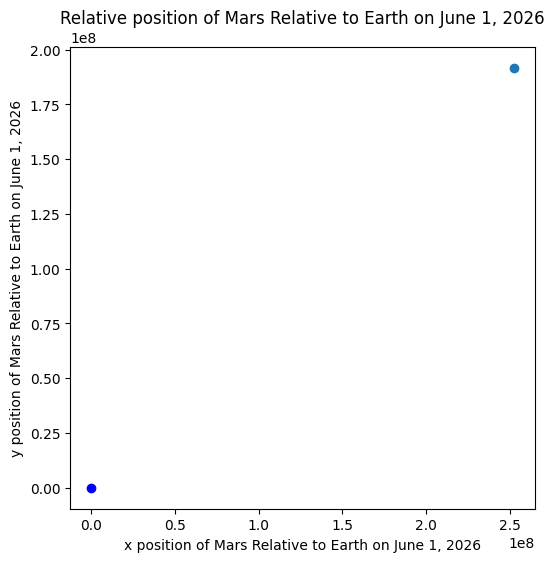

In [38]:
import matplotlib.pyplot as plt

x = pos[0] #x position coordinates of Mars relative to Earth
y = pos[1] #y position coordinates of Mars relative to Earth

plt.figure(figsize=(6,6))
plt.scatter(x,y, label="Mars's Path")
plt.scatter(0, 0, color='blue', label="Earth (Center)")
plt.xlabel("x position of Mars Relative to Earth on June 1, 2026")
plt.ylabel("y position of Mars Relative to Earth on June 1, 2026")
plt.title("Relative position of Mars Relative to Earth on June 1, 2026")
plt.show()

# If we want to make this graph continuous, we need to make a loop to track the positions now

In [39]:
et1 = spice.str2et("2026-01-01") #starting time is the first day of 2026
et2 = spice.str2et("2026-06-01") #ending time is the middle of 2026 (approximately)
time_steps = np.linspace(et1, et2, 1000) #1000 data points in between these 6 months

In [40]:
x_pos = []
y_pos = []

for et1 in time_steps:
    pos, lt = spice.spkpos(
    "MARS BARYCENTER",
    et1,
    "J2000",
    "NONE",
    "EARTH BARYCENTER"
    )
    x_pos.append(pos[0])
    y_pos.append(pos[1])

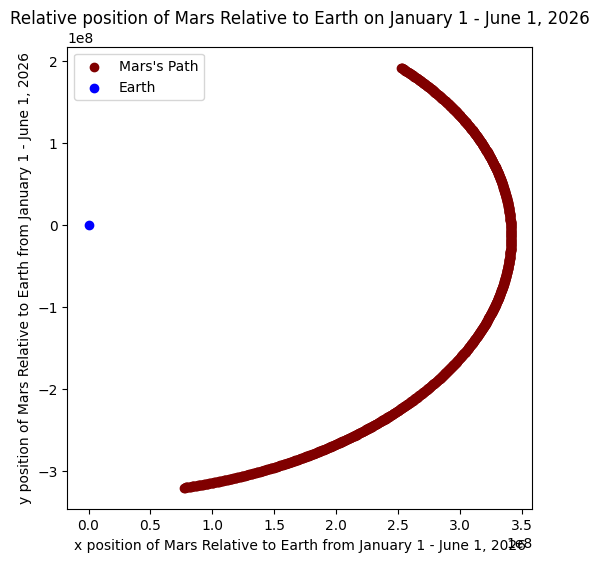

In [46]:
plt.figure(figsize=(6,6))
plt.scatter(x_pos,y_pos, label="Mars's Path", color = "maroon")
plt.scatter(0, 0, color='blue', label="Earth")
plt.xlabel("x position of Mars Relative to Earth from January 1 - June 1, 2026")
plt.ylabel("y position of Mars Relative to Earth from January 1 - June 1, 2026")
plt.title("Relative position of Mars Relative to Earth on January 1 - June 1, 2026")
plt.legend()
plt.show()